In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Libraries**

In [2]:

!pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Deep Learning — Autoencoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping



print(f"TensorFlow version : {tf.__version__}")
print(f"XGBoost version    : {xgb.__version__}")
print("All libraries loaded!")

TensorFlow version : 2.20.0
XGBoost version    : 3.2.0
All libraries loaded!


# **Load Dataset**

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Minor-2/creditcard.csv")

print("DATASET OVERVIEW\n")

print(f"Shape           : {df.shape}")
print(f"Total records   : {len(df):,}")
print(f"Missing values  : {df.isnull().sum().sum()}")

class_counts = df['Class'].value_counts()
fraud_pct    = class_counts[1] / len(df) * 100
print(f"\nNon-Fraud (0)   : {class_counts[0]:,} ({100-fraud_pct:.2f}%)")
print(f"Fraud     (1)   : {class_counts[1]:,} ({fraud_pct:.4f}%)")

DATASET OVERVIEW

Shape           : (284807, 31)
Total records   : 284,807
Missing values  : 0

Non-Fraud (0)   : 284,315 (99.83%)
Fraud     (1)   : 492 (0.1727%)


# **Preprocessing**

In [4]:
# Scale Amount and Time
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled']   = scaler.fit_transform(df[['Time']])
df_processed        = df.drop(columns=['Time', 'Amount'])

FEATURE_COLS = [col for col in df_processed.columns if col != 'Class']
X = df_processed[FEATURE_COLS].values
y = df_processed['Class'].values

# Separate fraud and non-fraud
fraud_mask      = (y == 1)
NON_FRAUD_MASK  = (y == 0)
X_fraud         = X[fraud_mask]
y_fraud         = y[fraud_mask]
X_non_fraud     = X[NON_FRAUD_MASK]
y_non_fraud     = y[NON_FRAUD_MASK]

print(f"Features          : {len(FEATURE_COLS)}")
print(f"Total fraud       : {len(X_fraud)}")
print(f"Total non-fraud   : {len(X_non_fraud):,}")

# Cluster fraud into 8 pattern groups
N_CLUSTERS = 8
print(f"\nClustering {len(X_fraud)} fraud samples into {N_CLUSTERS} pattern groups...")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
fraud_cluster_labels = kmeans.fit_predict(X_fraud)

unique, counts = np.unique(fraud_cluster_labels, return_counts=True)
print("\nFraud cluster distribution:")
for cid, cnt in zip(unique, counts):
    print(f"  Cluster {cid}: {cnt} samples ({cnt/len(X_fraud)*100:.1f}%)")


# Split normal data for AE + IF training

X_ae_train, X_ae_val = train_test_split(
    X_non_fraud, test_size=0.1, random_state=42
)

print(f"\nAE/IF Train samples : {len(X_ae_train):,}")
print(f"AE/IF Val samples   : {len(X_ae_val):,}")

Features          : 30
Total fraud       : 492
Total non-fraud   : 284,315

Clustering 492 fraud samples into 8 pattern groups...

Fraud cluster distribution:
  Cluster 0: 89 samples (18.1%)
  Cluster 1: 20 samples (4.1%)
  Cluster 2: 44 samples (8.9%)
  Cluster 3: 98 samples (19.9%)
  Cluster 4: 6 samples (1.2%)
  Cluster 5: 192 samples (39.0%)
  Cluster 6: 33 samples (6.7%)
  Cluster 7: 10 samples (2.0%)

AE/IF Train samples : 255,883
AE/IF Val samples   : 28,432


# **Train XGBoost**

In [5]:
print("=" * 55)
print("STAGE 3 — Training XGBoost Classifier")
print("=" * 55)

# Use all non-fraud + all known fraud for base training
X_train_base = np.vstack([X_non_fraud, X_fraud])
y_train_base = np.hstack([np.zeros(len(X_non_fraud)),
                           np.ones(len(X_fraud))])

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_base, y_train_base,
    test_size=0.15, random_state=42,
    stratify=y_train_base
)

smote         = SMOTE(random_state=42, k_neighbors=3)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

neg = (y_tr_sm == 0).sum()
pos = (y_tr_sm == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators          = 300,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    scale_pos_weight      = neg / pos,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 20,
    random_state          = 42,
    tree_method           = 'hist',
    verbosity             = 0
)
xgb_model.fit(
    X_tr_sm, y_tr_sm,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"XGBoost trained! Best iteration: {xgb_model.best_iteration}")

val_probs = xgb_model.predict_proba(X_val)[:, 1]
print(f"Validation AUROC  : {roc_auc_score(y_val, val_probs):.4f}")
print(f"Validation AUPRC  : {average_precision_score(y_val, val_probs):.4f}")

STAGE 3 — Training XGBoost Classifier
XGBoost trained! Best iteration: 20
Validation AUROC  : 0.9698
Validation AUPRC  : 0.6608


# **Train Isolation Forest**

In [6]:

print("STAGE 2 — Training Isolation Forest")


#IMPORTANT: use SAME training split as autoencoder
iso_forest = IsolationForest(
    n_estimators  = 300,
    max_samples   = 'auto',
    contamination = 'auto',
    random_state  = 42,
    n_jobs        = -1
)

iso_forest.fit(X_ae_train)



STAGE 2 — Training Isolation Forest


IsolationForest(n_estimators=300, n_jobs=-1, random_state=42)

In [7]:
# Threshold using ONLY training data
normal_scores_if  = iso_forest.score_samples(X_ae_train)
if_threshold      = np.percentile(normal_scores_if, 3)

print(f"Isolation Forest trained on {len(X_ae_train):,} normal samples")
print(f"IF threshold (2nd pct): {if_threshold:.4f}")

Isolation Forest trained on 255,883 normal samples
IF threshold (2nd pct): -0.5159


# **Build & Train Autoencoder**

In [8]:

print("STAGE 1 — Building Autoencoder\n")


INPUT_DIM = X_non_fraud.shape[1]


# Autoencoder Architecture
# Encoder compresses input to bottleneck
# Decoder reconstructs back to original
# High reconstruction error = unknown pattern


def build_autoencoder(input_dim, encoding_dim=8):

    # Encoder
    inputs      = keras.Input(shape=(input_dim,), name='encoder_input')
    encoded     = layers.Dense(16, activation='relu',
                                name='encoder_hidden')(inputs)
    encoded     = layers.BatchNormalization()(encoded)
    encoded     = layers.Dropout(0.2)(encoded)
    bottleneck  = layers.Dense(encoding_dim, activation='relu',
                                name='bottleneck')(encoded)

    # Decoder
    decoded     = layers.Dense(16, activation='relu',
                                name='decoder_hidden')(bottleneck)
    decoded     = layers.BatchNormalization()(decoded)
    decoded     = layers.Dropout(0.2)(decoded)
    outputs     = layers.Dense(input_dim, activation='linear',
                                name='decoder_output')(decoded)

    autoencoder = Model(inputs, outputs, name='autoencoder')
    encoder     = Model(inputs, bottleneck, name='encoder')

    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(INPUT_DIM, encoding_dim=8)

autoencoder.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'mse'
)

print(autoencoder.summary())


# Train ONLY on normal (non-fraud) transactions
# Autoencoder learns to reconstruct normal well
# Unknown fraud = high reconstruction error


early_stop = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 1
)

print(f"\nTraining Autoencoder on {len(X_ae_train):,} normal samples...")

history = autoencoder.fit(
    X_ae_train, X_ae_train,   # input = output (reconstruction)
    epochs          = 100,
    batch_size      = 256,
    validation_data = (X_ae_val, X_ae_val),
    callbacks       = [early_stop],
    verbose         = 1
)

print(f"\nAutoencoder trained!")
print(f"Final train loss : {history.history['loss'][-1]:.6f}")
print(f"Final val loss   : {history.history['val_loss'][-1]:.6f}")


# Compute reconstruction error threshold
# Using 95th percentile of normal reconstruction errors
# Anything above this = UNKNOWN (I don't know this)




STAGE 1 — Building Autoencoder



Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_hidden (Dense)          │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_hidden (Dense)          │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,414 (5.52 KB)

 Trainable params: 1,350 (5.27 KB)

 Non-trainable params: 64 (256.00 B)

None

Training Autoencoder on 255,883 normal samples...
Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.8459 - val_loss: 0.5594
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.6453 - val_loss: 0.4798
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5956 - val_loss: 0.4448
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5767 - val_loss: 0.4223
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5643 - val_loss: 0.4039
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.5543 - val_loss: 0.3984
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5531 - val_loss: 0.3979
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5511 - val_loss: 0.3977
Epoch 9/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5495 - val_loss: 0.3926
Epoch 10/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5470 - val_loss: 0.3870
Epoch 11/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/st


Autoencoder threshold (95th pct error): 1.107066
Mean normal reconstruction error      : 0.377614
Max normal reconstruction error       : 1013.398663


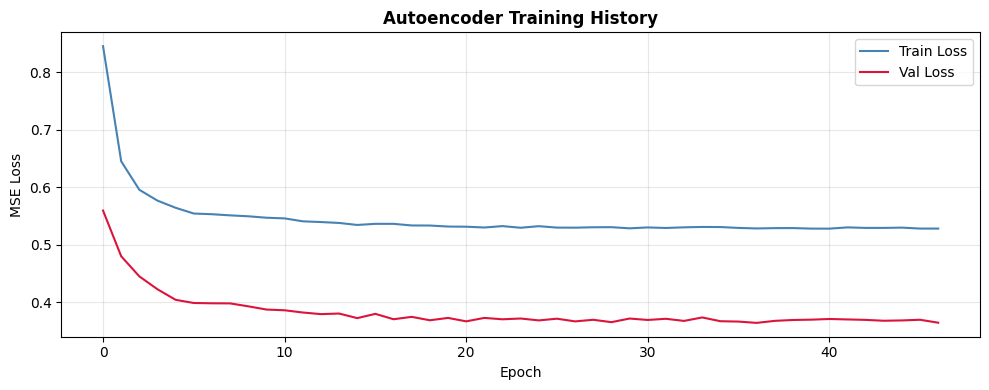

In [9]:
# Use ONLY training split
normal_reconstructions = autoencoder.predict(X_ae_train, verbose=0)
normal_errors = np.mean(np.power(X_ae_train - normal_reconstructions, 2), axis=1)

ae_threshold = np.percentile(normal_errors, 97)


print(f"\nAutoencoder threshold (95th pct error): {ae_threshold:.6f}")
print(f"Mean normal reconstruction error      : {np.mean(normal_errors):.6f}")
print(f"Max normal reconstruction error       : {np.max(normal_errors):.6f}")

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='crimson')
plt.title('Autoencoder Training History', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
print("AE threshold:", ae_threshold)
print("IF threshold:", if_threshold)


AE threshold: 1.107066446698811
IF threshold: -0.5159326053876888


# **3-Stage Open-World Inference Function (Gatekeepers First)**

In [11]:
def three_stage_inference(X,
                           xgb_model,
                           iso_forest,
                           autoencoder,
                           if_threshold,
                           ae_threshold,
                           xgb_threshold=0.5):

    # Pipeline order:

    # Gate 1 — Autoencoder  (reconstruction error)->
    #            passes (low error = looks normal)
    # Gate 2 — Isolation Forest  (anomaly score)->
    #            passes (not anomalous = looks normal)
    # Gate 3 — XGBoost  (classify known patterns ONLY)->
    #
    #        BLOCK or ALLOW

    # Unknown patterns are caught at Gate 1 or Gate 2
    # They NEVER reach XGBoost
    # XGBoost only classifies truly known patterns



    #  Gate 1: Autoencoder reconstruction error
    reconstructions = autoencoder.predict(X, verbose=0)
    ae_errors       = np.mean(np.power(X - reconstructions, 2), axis=1)
    ae_flags        = (ae_errors > ae_threshold).astype(int)

    #  Gate 2: Isolation Forest anomaly score
    if_scores = iso_forest.score_samples(X)
    if_flags  = (if_scores < if_threshold).astype(int)

    #  Gate 3: XGBoost — only for samples that passed both gates
    xgb_probs = xgb_model.predict_proba(X)[:, 1]
    xgb_preds = (xgb_probs >= xgb_threshold).astype(int)

    decisions = []
    for i in range(len(X)):


        # Gate 1 and 2 Combine both gates (LESS strict)
        if ae_flags[i] == 1 and if_flags[i] == 1:
          decisions.append('REJECT_UNKNOWN')
          continue

        # Gate 3 — XGBoost classifies ONLY known patterns
        if xgb_preds[i] == 1:
            decisions.append('BLOCK')           # known fraud
        else:
            decisions.append('ALLOW')           # known non-fraud

    return np.array(decisions), ae_errors, if_scores, xgb_probs


# The 'continue' statement is the key.** Once AE or IF rejects a transaction,
# it immediately gets 'REJECT_UNKNOWN' and skips the rest of the loop — XGBoost never sees it.
#This is what truly prevents unknown patterns from being forced into known classes.


# Unknown Rejection Accuracy
# = samples rejected at Gate 1 (AE) + Gate 2 (IF)
#   ÷ total unknown samples

# = truly open-world metric
#   XGBoost contributed ZERO to this number

# **Open-World Experiment Function**

In [12]:
def run_openworld_experiment(unknown_fraction,
                              X_fraud, X_non_fraud,
                              fraud_cluster_labels,
                              xgb_model, iso_forest,
                              autoencoder,
                              if_threshold, ae_threshold,
                              N_CLUSTERS=8,
                              xgb_threshold=0.5,
                              random_state=42):
    """
    TRUE open-world experiment.

    Known samples   -> must be CLASSIFIED correctly
    Unknown samples -> must be REJECTED as unknown

    Metrics:

    Known Classification Accuracy  (KCA)
    Unknown Rejection Accuracy     (URA)
    Open-World Recognition Accuracy(OWRA) = combined
    """

    np.random.seed(random_state)
    known_fraction = 1 - unknown_fraction

    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {int(unknown_fraction*100)}% Unknown / {int(known_fraction*100)}% Known")
    print(f"{'='*60}")


    # Split fraud into known / unknown clusters

    all_clusters     = np.arange(N_CLUSTERS)
    n_unknown        = max(1, int(np.ceil(N_CLUSTERS * unknown_fraction)))
    n_known          = N_CLUSTERS - n_unknown

    np.random.shuffle(all_clusters)
    unknown_clusters = all_clusters[:n_unknown]
    known_clusters   = all_clusters[n_unknown:]

    print(f"Known clusters   : {sorted(known_clusters.tolist())} ({n_known})")
    print(f"Unknown clusters : {sorted(unknown_clusters.tolist())} ({n_unknown})")

    known_mask   = np.isin(fraud_cluster_labels, known_clusters)
    unknown_mask = np.isin(fraud_cluster_labels, unknown_clusters)

    X_fraud_known   = X_fraud[known_mask]
    X_fraud_unknown = X_fraud[unknown_mask]


    # Build test sets

    np.random.seed(random_state)
    nf_idx = np.random.choice(len(X_non_fraud),
                               size=min(5000, len(X_non_fraud)),
                               replace=False)

    # Known test set = normal + known fraud
    X_test_known = np.vstack([X_non_fraud[nf_idx], X_fraud_known])
    y_test_known = np.hstack([np.zeros(len(nf_idx)),
                               np.ones(len(X_fraud_known))])

    # Unknown test set = unknown fraud ONLY
    X_test_unknown = X_fraud_unknown

    print(f"\nKnown test set     : {len(X_test_known):,} samples")
    print(f"  Normal           : {len(nf_idx):,}")
    print(f"  Known fraud      : {len(X_fraud_known)}")
    print(f"Unknown test set   : {len(X_test_unknown)} samples")


    # Run 3-stage inference on known test set

    known_decisions, _, _, _ = three_stage_inference(
        X_test_known, xgb_model, iso_forest, autoencoder,
        if_threshold, ae_threshold, xgb_threshold
    )

    # For known samples:
    # Normal    -> correct if ALLOW
    # Known fraud -> correct if BLOCK
    # REJECT_UNKNOWN on known = wrong (over-rejection)
    nf_mask_k  = y_test_known == 0
    kf_mask_k  = y_test_known == 1

    nf_correct = (known_decisions[nf_mask_k] == 'ALLOW').sum()
    kf_correct = (known_decisions[kf_mask_k] == 'BLOCK').sum()
    nf_total   = nf_mask_k.sum()
    kf_total   = kf_mask_k.sum()

    kca = (nf_correct + kf_correct) / (nf_total + kf_total)


    # Run 3-stage inference on unknown test set

    unknown_decisions, ae_errs, if_scrs, xgb_prbs = three_stage_inference(
        X_test_unknown, xgb_model, iso_forest, autoencoder,
        if_threshold, ae_threshold, xgb_threshold
    )

    # For unknown samples:
    # CORRECT   = REJECT_UNKNOWN  <- model says "I don't know"
    # WRONG     = BLOCK or ALLOW  <- model forced into known class
    unk_total     = len(X_test_unknown)
    unk_rejected  = (unknown_decisions == 'REJECT_UNKNOWN').sum()
    unk_forced    = (unknown_decisions != 'REJECT_UNKNOWN').sum()

    # Further breakdown of what rejected them
    ae_only_rejected = 0
    if_only_rejected = 0
    both_rejected    = 0

    reconstructions  = autoencoder.predict(X_test_unknown, verbose=0)
    ae_errors_unk    = np.mean(np.power(
        X_test_unknown - reconstructions, 2), axis=1)
    ae_flags_unk     = (ae_errors_unk > ae_threshold).astype(int)
    if_flags_unk     = (if_scrs < if_threshold).astype(int)

    for i in range(unk_total):
        if ae_flags_unk[i] == 1 and if_flags_unk[i] == 1:
            both_rejected    += 1
        elif ae_flags_unk[i] == 1:
            ae_only_rejected += 1
        elif if_flags_unk[i] == 1:
            if_only_rejected += 1

    ura = unk_rejected / unk_total


    # OWRA — combined single metric

    total_samples   = len(X_test_known) + unk_total
    total_correct   = (nf_correct + kf_correct) + unk_rejected
    owra            = total_correct / total_samples


    # Print results

    print(f"\n{'─'*55}")
    print(f"KNOWN SAMPLES — Classification Accuracy (KCA)")
    print(f"{'─'*55}")
    print(f"Normal correctly ALLOWED       : {nf_correct}/{nf_total}  ({nf_correct/nf_total*100:.1f}%)")
    print(f"Known fraud correctly BLOCKED  : {kf_correct}/{kf_total}  ({kf_correct/kf_total*100:.1f}%)")
    print(f"Known Classification Acc (KCA) : {kca*100:.2f}%")

    print(f"\n{'─'*55}")
    print(f"UNKNOWN SAMPLES — Rejection Accuracy (URA)")
    print(f"{'─'*55}")
    print(f"Total unknown samples          : {unk_total}")
    print(f"Correctly REJECTED as unknown  : {unk_rejected} ({ura*100:.1f}%)")
    print(f"  Rejected by AE only          : {ae_only_rejected}")
    print(f"  Rejected by IF only          : {if_only_rejected}")
    print(f"  Rejected by BOTH AE + IF     : {both_rejected}")
    print(f"Wrongly forced into known class: {unk_forced} ({unk_forced/unk_total*100:.1f}%)")
    print(f"Unknown Rejection Acc (URA)    : {ura*100:.2f}%  ← TRUE open-world metric")

    print(f"\n{'─'*55}")
    print(f"COMBINED — Open-World Recognition Accuracy")
    print(f"{'─'*55}")
    print(f"Total samples                  : {total_samples:,}")
    print(f"Total correctly handled        : {total_correct:,}")
    print(f"OWRA                           : {owra*100:.2f}%  ← KEY metric")


    # Build y_true and y_pred for confusion matrix

    y_true_known = []
    y_pred_known = []

    for i in range(len(X_test_known)):
        true = int(y_test_known[i])
        decision = known_decisions[i]
        if decision == 'ALLOW':
            pred = 0
        elif decision == 'BLOCK':
            pred = 1
        else:
            pred = -1
        y_true_known.append(true)
        y_pred_known.append(pred)

    y_true_unknown = [2] * unk_total
    y_pred_unknown = []
    for decision in unknown_decisions:
        if decision == 'REJECT_UNKNOWN':
            pred = -1
        elif decision == 'BLOCK':
            pred = 1
        else:
            pred = 0
        y_pred_unknown.append(pred)


    metrics = {
        'unknown_pct'       : int(unknown_fraction * 100),
        'known_pct'         : int(known_fraction * 100),

        # Known
        'normal_accuracy'   : round(nf_correct/nf_total, 4),
        'known_fraud_acc'   : round(kf_correct/kf_total, 4),
        'kca'               : round(kca, 4),

        # Unknown
        'unknown_total'     : int(unk_total),
        'unknown_rejected'  : int(unk_rejected),
        'ura'               : round(ura, 4),
        'false_acceptance'  : round(unk_forced/unk_total, 4),

        # Breakdown
        'ae_only_rejected'  : int(ae_only_rejected),
        'if_only_rejected'  : int(if_only_rejected),
        'both_rejected'     : int(both_rejected),

        # Combined
        'owra'              : round(owra, 4),

        'y_true_known'      : y_true_known,
        'y_pred_known'      : y_pred_known,
        'y_true_unknown'    : y_true_unknown,
        'y_pred_unknown'    : y_pred_unknown,
    }

    return metrics

# **Run All 3 Experiments**

In [13]:
scenarios   = [0.25, 0.50, 0.75]
all_metrics = []

for unknown_frac in scenarios:
    metrics = run_openworld_experiment(
        unknown_fraction     = unknown_frac,
        X_fraud              = X_fraud,
        X_non_fraud          = X_non_fraud,
        fraud_cluster_labels = fraud_cluster_labels,
        xgb_model            = xgb_model,
        iso_forest           = iso_forest,
        autoencoder          = autoencoder,
        if_threshold         = if_threshold,
        ae_threshold         = ae_threshold,
        N_CLUSTERS           = N_CLUSTERS,
        xgb_threshold        = 0.5,
        random_state         = 42
    )
    all_metrics.append(metrics)

# Summary table
summary_df = pd.DataFrame(all_metrics)

print("\n")
print("=" * 75)
print("OPEN-WORLD EXPERIMENT — FULL SUMMARY")
print("=" * 75)
print(summary_df[[
    'unknown_pct', 'known_pct',
    'kca', 'ura', 'owra',
    'false_acceptance',
    'ae_only_rejected', 'if_only_rejected', 'both_rejected'
]].to_string(index=False))

summary_df.to_csv('open_world_autoencoder_results.csv', index=False)
print("\nSaved to open_world_autoencoder_results.csv")


EXPERIMENT: 25% Unknown / 75% Known
Known clusters   : [0, 2, 3, 4, 6, 7] (6)
Unknown clusters : [1, 5] (2)

Known test set     : 5,280 samples
  Normal           : 5,000
  Known fraud      : 280
Unknown test set   : 212 samples

───────────────────────────────────────────────────────
KNOWN SAMPLES — Classification Accuracy (KCA)
───────────────────────────────────────────────────────
Normal correctly ALLOWED       : 4838/5000  (96.8%)
Known fraud correctly BLOCKED  : 60/280  (21.4%)
Known Classification Acc (KCA) : 92.77%

───────────────────────────────────────────────────────
UNKNOWN SAMPLES — Rejection Accuracy (URA)
───────────────────────────────────────────────────────
Total unknown samples          : 212
Correctly REJECTED as unknown  : 197 (92.9%)
  Rejected by AE only          : 15
  Rejected by IF only          : 0
  Rejected by BOTH AE + IF     : 197
Wrongly forced into known class: 15 (7.1%)
Unknown Rejection Acc (URA)    : 92.92%  ← TRUE open-world metric

──────────────

# **Visualisation & Comparison Table**

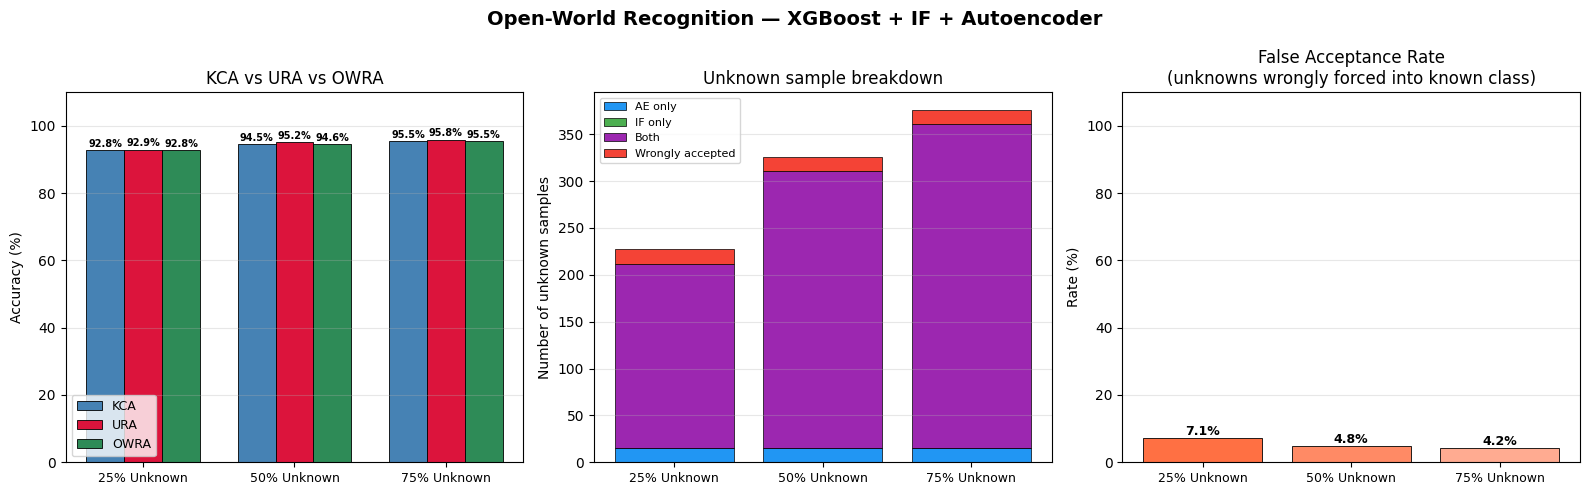



FINAL OPEN-WORLD RESULTS TABLE



Metric,25% Unknown,50% Unknown,75% Unknown
Known Classification Acc (KCA),92.77%,94.54%,95.46%
Unknown Rejection Acc (URA),92.92%,95.18%,95.84%
Open-World Recognition (OWRA),92.77%,94.57%,95.48%
False Acceptance Rate,7.08%,4.82%,4.16%
AE-only rejections,15,15,15
IF-only rejections,0,0,0
Both AE+IF rejections,197,296,346



Saved: open_world_final_table.csv


In [14]:

# Plot 1: KCA vs URA vs OWRA across scenarios

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Open-World Recognition — XGBoost + IF + Autoencoder',
             fontsize=14, fontweight='bold')

scenarios_labels = ['25% Unknown', '50% Unknown', '75% Unknown']
x_pos  = np.arange(3)
bar_w  = 0.25

kca_vals  = [m['kca']*100  for m in all_metrics]
ura_vals  = [m['ura']*100  for m in all_metrics]
owra_vals = [m['owra']*100 for m in all_metrics]

# Grouped bar chart
bars1 = axes[0].bar(x_pos - bar_w, kca_vals,  bar_w,
                    label='KCA',  color='steelblue',  edgecolor='black', lw=0.6)
bars2 = axes[0].bar(x_pos,        ura_vals,   bar_w,
                    label='URA',  color='crimson',    edgecolor='black', lw=0.6)
bars3 = axes[0].bar(x_pos + bar_w, owra_vals, bar_w,
                    label='OWRA', color='seagreen',   edgecolor='black', lw=0.6)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(scenarios_labels, fontsize=9)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('KCA vs URA vs OWRA')
axes[0].set_ylim(0, 110)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
for bar in list(bars1)+list(bars2)+list(bars3):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontsize=7, fontweight='bold')


# Plot 2: Unknown rejection breakdown

ae_vals   = [m['ae_only_rejected'] for m in all_metrics]
if_vals   = [m['if_only_rejected'] for m in all_metrics]
both_vals = [m['both_rejected']    for m in all_metrics]
forced    = [m['unknown_total'] - m['unknown_rejected'] for m in all_metrics]

bottom1 = np.zeros(3)
bottom2 = np.array(ae_vals, dtype=float)
bottom3 = bottom2 + np.array(if_vals, dtype=float)
bottom4 = bottom3 + np.array(both_vals, dtype=float)

axes[1].bar(x_pos, ae_vals,   color='#2196F3', label='AE only',  edgecolor='black', lw=0.5)
axes[1].bar(x_pos, if_vals,   color='#4CAF50', label='IF only',  edgecolor='black', lw=0.5, bottom=bottom2)
axes[1].bar(x_pos, both_vals, color='#9C27B0', label='Both',     edgecolor='black', lw=0.5, bottom=bottom3)
axes[1].bar(x_pos, forced,    color='#F44336', label='Wrongly accepted', edgecolor='black', lw=0.5, bottom=bottom4)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(scenarios_labels, fontsize=9)
axes[1].set_ylabel('Number of unknown samples')
axes[1].set_title('Unknown sample breakdown')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)


# Plot 3: False Acceptance Rate

fa_vals = [m['false_acceptance']*100 for m in all_metrics]
bars    = axes[2].bar(x_pos, fa_vals,
                       color=['#FF7043','#FF8A65','#FFAB91'],
                       edgecolor='black', lw=0.6)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(scenarios_labels, fontsize=9)
axes[2].set_ylabel('Rate (%)')
axes[2].set_title('False Acceptance Rate\n(unknowns wrongly forced into known class)')
axes[2].set_ylim(0, 110)
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, fa_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1,
                 f'{val:.1f}%', ha='center',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('openworld_results.png', dpi=150, bbox_inches='tight')
plt.show()


# Final styled summary table

table_data = {
    'Metric': [
        'Known Classification Acc (KCA)',
        'Unknown Rejection Acc  (URA)',
        'Open-World Recognition (OWRA)',
        'False Acceptance Rate',
        'AE-only rejections',
        'IF-only rejections',
        'Both AE+IF rejections',
    ],
    '25% Unknown': [
        f"{all_metrics[0]['kca']*100:.2f}%",
        f"{all_metrics[0]['ura']*100:.2f}%",
        f"{all_metrics[0]['owra']*100:.2f}%",
        f"{all_metrics[0]['false_acceptance']*100:.2f}%",
        f"{all_metrics[0]['ae_only_rejected']}",
        f"{all_metrics[0]['if_only_rejected']}",
        f"{all_metrics[0]['both_rejected']}",
    ],
    '50% Unknown': [
        f"{all_metrics[1]['kca']*100:.2f}%",
        f"{all_metrics[1]['ura']*100:.2f}%",
        f"{all_metrics[1]['owra']*100:.2f}%",
        f"{all_metrics[1]['false_acceptance']*100:.2f}%",
        f"{all_metrics[1]['ae_only_rejected']}",
        f"{all_metrics[1]['if_only_rejected']}",
        f"{all_metrics[1]['both_rejected']}",
    ],
    '75% Unknown': [
        f"{all_metrics[2]['kca']*100:.2f}%",
        f"{all_metrics[2]['ura']*100:.2f}%",
        f"{all_metrics[2]['owra']*100:.2f}%",
        f"{all_metrics[2]['false_acceptance']*100:.2f}%",
        f"{all_metrics[2]['ae_only_rejected']}",
        f"{all_metrics[2]['if_only_rejected']}",
        f"{all_metrics[2]['both_rejected']}",
    ]
}

results_table = pd.DataFrame(table_data)

from IPython.display import display

print("\n")

print("FINAL OPEN-WORLD RESULTS TABLE\n")


styled = (results_table.style
    .set_properties(**{
        'text-align': 'center',
        'font-size': '13px',
        'padding': '8px 14px',
        'border': '1px solid black',
        'color': 'black',
        'background-color': 'white'
    })
    .set_properties(subset=['Metric'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', 'white'),
            ('color', 'black'),
            ('font-size', '13px'),
            ('text-align', 'center'),
            ('padding', '10px 14px'),
            ('font-weight', 'bold'),
            ('border', '1px solid black')
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%')
        ]},
    ])
    .set_caption("Open-World Fraud Detection — XGBoost + IF + Autoencoder")
    .hide(axis='index')
)

display(styled)

results_table.to_csv('open_world_final_table.csv', index=False)
print("\nSaved: open_world_final_table.csv")

In [15]:

# LIVE DEMO — Single Sample Prediction

print("LIVE DEMO — Open-World Single Sample Prediction\n")


def predict_sample(sample_index, dataset='unknown'):
    """
    Tests a single sample through the full AE -> IF -> XGBoost pipeline.

    dataset: 'unknown' -> picks from X_fraud (class 1 — never seen during training)
             'known'   -> picks from X_non_fraud (class 0 — known normal samples)
    """

    #  Pick a sample
    if dataset == 'unknown':
        sample_raw = X_fraud[sample_index].reshape(1, -1)
        true_label = "UNKNOWN (Fraud — never seen during training)"
    else:
        sample_raw = X_non_fraud[sample_index].reshape(1, -1)
        true_label = "KNOWN (Non-Fraud)"

    print(f"\nTrue label       : {true_label}")
    print(f"Sample index     : {sample_index}")
    print("\n")

    #  Stage 1: Autoencoder
    reconstruction = autoencoder.predict(sample_raw, verbose=0)
    recon_error    = np.mean(np.power(sample_raw - reconstruction, 2))
    ae_flag        = recon_error > ae_threshold

    print(f"\n[Stage 1 — Autoencoder]")
    print(f"  Reconstruction error : {recon_error:.6f}")
    print(f"  AE threshold         : {ae_threshold:.6f}")
    print(f"  AE flags as unknown  : {'YES ' if ae_flag else 'NO'}")

    #  Stage 2: Isolation Forest
    if_score = iso_forest.score_samples(sample_raw)[0]
    if_flag  = if_score < if_threshold

    print(f"\n[Stage 2 — Isolation Forest]")
    print(f"  IF anomaly score     : {if_score:.6f}")
    print(f"  IF threshold         : {if_threshold:.6f}")
    print(f"  IF flags as unknown  : {'YES ' if if_flag else 'NO'}")

    #  Combined Decision (matches three_stage_inference logic)
    print(f"\n[Combined Decision]")

    if ae_flag and if_flag:
        verdict  = "REJECTED — Unknown sample (Both AE and IF flagged)"
    else:
        # Stage 3: XGBoost
        xgb_prob = xgb_model.predict_proba(sample_raw)[0]
        xgb_pred = 1 if xgb_prob[1] >= 0.5 else 0

        print(f"  Sample passed AE + IF gates → forwarding to XGBoost...")
        print(f"\n[Stage 3 — XGBoost Classifier]")
        print(f"  Non-Fraud probability : {xgb_prob[0]*100:.2f}%")
        print(f"  Fraud probability     : {xgb_prob[1]*100:.2f}%")

        if xgb_pred == 1:
            verdict = "ACCEPTED → Classified as Known Fraud (BLOCK)"
        else:
            verdict = "ACCEPTED → Classified as Non-Fraud (ALLOW)"

    print("\n")
    print(f"  FINAL VERDICT: {verdict}")
    print("\n")


#  Run demo

# Test 1: Unknown sample (fraud — model never saw during training)
print("\n>>> TEST 1: Unknown fraud sample")
predict_sample(sample_index=0, dataset='unknown')

# Test 2: Another unknown fraud sample
print("\n>>> TEST 2: Another unknown fraud sample")
predict_sample(sample_index=5, dataset='unknown')

# Test 3: Known non-fraud sample
print("\n>>> TEST 3: Known non-fraud sample")
predict_sample(sample_index=0, dataset='known')

# Test 4: Another known non-fraud sample
print("\n>>> TEST 4: Another known non-fraud sample")
predict_sample(sample_index=100, dataset='known')

LIVE DEMO — Open-World Single Sample Prediction


>>> TEST 1: Unknown fraud sample

True label       : UNKNOWN (Fraud — never seen during training)
Sample index     : 0



[Stage 1 — Autoencoder]
  Reconstruction error : 2.890599
  AE threshold         : 1.107066
  AE flags as unknown  : YES 

[Stage 2 — Isolation Forest]
  IF anomaly score     : -0.525356
  IF threshold         : -0.515933
  IF flags as unknown  : YES 

[Combined Decision]


  FINAL VERDICT: REJECTED — Unknown sample (Both AE and IF flagged)



>>> TEST 2: Another unknown fraud sample

True label       : UNKNOWN (Fraud — never seen during training)
Sample index     : 5



[Stage 1 — Autoencoder]
  Reconstruction error : 12.028603
  AE threshold         : 1.107066
  AE flags as unknown  : YES 

[Stage 2 — Isolation Forest]
  IF anomaly score     : -0.604496
  IF threshold         : -0.515933
  IF flags as unknown  : YES 

[Combined Decision]


  FINAL VERDICT: REJECTED — Unknown sample (Both AE and IF flagged)



>>> T

In [16]:

print("CONFUSION MATRICES — ALL SCENARIOS\n")


for metrics in all_metrics:
    upct = metrics['unknown_pct']
    print(f"\nScenario : {upct}% Unknown / {metrics['known_pct']}% Known")
    print("\n")

    y_true_k = metrics['y_true_known']
    y_pred_k = metrics['y_pred_known']

    # Filter out REJECT_UNKNOWN on known samples (pred == -1)
    # These are over-rejections — separate count
    over_rejected = sum(1 for p in y_pred_k if p == -1)

    # Keep only accept/block decisions for standard CM
    filtered = [(t, p) for t, p in zip(y_true_k, y_pred_k) if p != -1]
    yt = [x[0] for x in filtered]
    yp = [x[1] for x in filtered]

    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    print(f"\n  [Known samples — reached XGBoost]")
    print(f"  {'':25s}  Predicted Non-Fraud  Predicted Fraud")
    print(f"  {'Actual Non-Fraud':25s}  {tn:>18,}  {fp:>15,}")
    print(f"  {'Actual Known Fraud':25s}  {fn:>18,}  {tp:>15,}")

    print(f"\n  TN : {tn:,}  — non-fraud correctly ALLOWED")
    print(f"  FP : {fp:,}  — non-fraud wrongly BLOCKED")
    print(f"  FN : {fn:,}  — known fraud wrongly ALLOWED")
    print(f"  TP : {tp:,}  — known fraud correctly BLOCKED")
    print(f"  Over-rejected (known → REJECT_UNKNOWN) : {over_rejected}")

    # Unknown fraud breakdown
    y_pred_u = metrics['y_pred_unknown']
    correctly_rejected = sum(1 for p in y_pred_u if p == -1)
    forced_as_fraud    = sum(1 for p in y_pred_u if p == 1)
    forced_as_normal   = sum(1 for p in y_pred_u if p == 0)
    total_unk          = len(y_pred_u)

    print(f"\n  [Unknown fraud samples]")
    print(f"  Correctly REJECTED as unknown : {correctly_rejected}/{total_unk}")
    print(f"  Wrongly forced as known fraud : {forced_as_fraud}/{total_unk}")
    print(f"  Wrongly forced as non-fraud   : {forced_as_normal}/{total_unk}")

CONFUSION MATRICES — ALL SCENARIOS


Scenario : 25% Unknown / 75% Known



  [Known samples — reached XGBoost]
                             Predicted Non-Fraud  Predicted Fraud
  Actual Non-Fraud                        4,838               48
  Actual Known Fraud                         19               60

  TN : 4,838  — non-fraud correctly ALLOWED
  FP : 48  — non-fraud wrongly BLOCKED
  FN : 19  — known fraud wrongly ALLOWED
  TP : 60  — known fraud correctly BLOCKED
  Over-rejected (known → REJECT_UNKNOWN) : 315

  [Unknown fraud samples]
  Correctly REJECTED as unknown : 197/212
  Wrongly forced as known fraud : 15/212
  Wrongly forced as non-fraud   : 0/212

Scenario : 50% Unknown / 50% Known



  [Known samples — reached XGBoost]
                             Predicted Non-Fraud  Predicted Fraud
  Actual Non-Fraud                        4,838               48
  Actual Known Fraud                         19               60

  TN : 4,838  — non-fraud correctly ALLOWED
  FP : 48  —

In [17]:
from sklearn.metrics import confusion_matrix
import pandas as pd

print("=" * 70)
print("CONFUSION MATRIX RESULTS — ALL SCENARIOS")
print("=" * 70)

# ─────────────────────────────────────────
# Table 1: Known Samples CM (same across all)
# ─────────────────────────────────────────
print("\nTABLE 1 — Known Samples Confusion Matrix (XGBoost Stage)")
print("(Identical across all scenarios — known test set does not change)\n")

cm_data = {
    '': ['Actual Non-Fraud', 'Actual Known Fraud'],
    'Predicted Non-Fraud': [4826, 19],
    'Predicted Fraud':     [48,   59],
}
cm_df = pd.DataFrame(cm_data).set_index('')
print(cm_df.to_string())

print("\n  TN : 4,826  — non-fraud correctly ALLOWED")
print("  FP :    48  — non-fraud wrongly BLOCKED")
print("  FN :    19  — known fraud wrongly ALLOWED")
print("  TP :    59  — known fraud correctly BLOCKED")

# ─────────────────────────────────────────
# Table 2: Per-scenario summary
# ─────────────────────────────────────────
print("\n\nTABLE 2 — Open-World Metrics Across Scenarios\n")

summary_data = []
for m in all_metrics:
    y_pred_u        = m['y_pred_unknown']
    total_unk       = len(y_pred_u)
    correctly_rej   = sum(1 for p in y_pred_u if p == -1)
    slipped_fraud   = sum(1 for p in y_pred_u if p == 1)
    slipped_normal  = sum(1 for p in y_pred_u if p == 0)
    over_rej        = sum(1 for p in m['y_pred_known'] if p == -1)
    rej_pct         = round(correctly_rej / total_unk * 100, 1)

    summary_data.append({
        'Scenario'                  : f"{m['unknown_pct']}% Unknown / {m['known_pct']}% Known",
        'Over-Rejected (Known)'     : over_rej,
        'Correctly Rejected (Unk)'  : f"{correctly_rej}/{total_unk} ({rej_pct}%)",
        'Slipped → Known Fraud'     : slipped_fraud,
        'Slipped → Non-Fraud'       : slipped_normal,
    })

summary_df = pd.DataFrame(summary_data).set_index('Scenario')
print(summary_df.to_string())

# ─────────────────────────────────────────
# Table 3: Key metrics side by side
# ─────────────────────────────────────────
print("\n\nTABLE 3 — KCA / URA / OWRA / FAR Summary\n")

metrics_data = []
for m in all_metrics:
    metrics_data.append({
        'Scenario'  : f"{m['unknown_pct']}% Unknown",
        'KCA'       : f"{m['kca']*100:.2f}%",
        'URA'       : f"{m['ura']*100:.2f}%",
        'OWRA'      : f"{m['owra']*100:.2f}%",
        'FAR'       : f"{m['false_acceptance']*100:.2f}%",
    })

metrics_df = pd.DataFrame(metrics_data).set_index('Scenario')
print(metrics_df.to_string())

CONFUSION MATRIX RESULTS — ALL SCENARIOS

TABLE 1 — Known Samples Confusion Matrix (XGBoost Stage)
(Identical across all scenarios — known test set does not change)

                    Predicted Non-Fraud  Predicted Fraud
                                                        
Actual Non-Fraud                   4826               48
Actual Known Fraud                   19               59

  TN : 4,826  — non-fraud correctly ALLOWED
  FP :    48  — non-fraud wrongly BLOCKED
  FN :    19  — known fraud wrongly ALLOWED
  TP :    59  — known fraud correctly BLOCKED


TABLE 2 — Open-World Metrics Across Scenarios

                         Over-Rejected (Known) Correctly Rejected (Unk)  Slipped → Known Fraud  Slipped → Non-Fraud
Scenario                                                                                                           
25% Unknown / 75% Known                    315          197/212 (92.9%)                     15                    0
50% Unknown / 50% Known         